### Summary of Experiments

This notebook documents experiments using a Convoltional Variational Autoencoder for EEG feature extraction, followed by MLP classification. The CVAE architecture is defined in `cvae.py` and data preprocessing in `data_prep.py.` The experiments investigate how two hyper-parameters (latent space and KL divergence weight) affect reconstruction quality, latent space structure and classification performance.

**Experiment 1: Latent Dimension Sweep for Classification Performance**

CVAEs were trained across latent dimension 6, 8, 12, and 16. The `z-mean` output of each trained encoder was used to train a separate MLP classifier. A `latend_dim=8` yielded the best validation accuracy (0.37), suggesting it strikes the best balance between compression and retaining discriminative information. Smaller dimensions underfit, while larger ones risk overfitting and did not improve classification.

**Experiment 2: Latent Space Visualization**

Dimensionality reduction techniques (t-SNE, PCA, UMAP) were applied to the `z-mean` of the test set for the best performing latent dimension. No clear class separation was visible in 2D projections suggesting that intra-class variance (background brain activity and noise) dominates inter-class variance (motor imagery signals). Despite this, the downstream MLP classifier still extracted useful discriminative information from the 8-dimensional latent space, indicating that class structure exists but is not linearly separable in low dimensional projections.

**Experiment 3: Latent Dimension and KL Weight Sweep for Reconstruction Quality**

CVAEs were trained across KL weights of 1e-4, 1e-3, 1e-2, and 1e-1; and across latent dimensions of 2, 6, 8, 12, 16, and 24. Increasing the KL weight pushes the latent space towards a standard normal distribution producing smoother structure but degrading reconstruction fidelity. Decreasing the KL weight prioritizes reconstruction at the cost of latent space regularity. The reconstruction grid `plots/reconstruction_grid.png` shows this trend across all combinations.







In [2]:
import os

IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/Colab Notebooks/cvae_project/"
    os.chdir(base_path)
else:
    base_path = "."

Mounted at /content/drive


In [3]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 58.5 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.


In [4]:
import pandas as pd
import numpy as np
from tensorflow import keras
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten,Dropout
from tensorflow.keras.layers import Conv2D,BatchNormalization,MaxPooling2D,Reshape
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras import models
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap


In [5]:
# ----------------------------
# File Imports
# ----------------------------
from src.models import cvae
from src.preprocessing import data_prep as dp


In [6]:
# ----------------------------
# Loading Data
# ----------------------------
X_test = np.load(base_path + "data/X_test.npy")
y_test = np.load(base_path + "data/y_test.npy")
person_train_valid = np.load(base_path +"data/person_train_valid.npy")
X_train_valid = np.load(base_path +"data/X_train_valid.npy")
y_train_valid = np.load(base_path +"data/y_train_valid.npy")
person_test = np.load(base_path +"data/person_test.npy")

Event Related Potential (ERP): Class-wise averaging across many trials cancels out random noise and reveals the consistent signal pattern associated with each class. This helps validate that the data actually contains class-discriminative information before feeding it to any model.

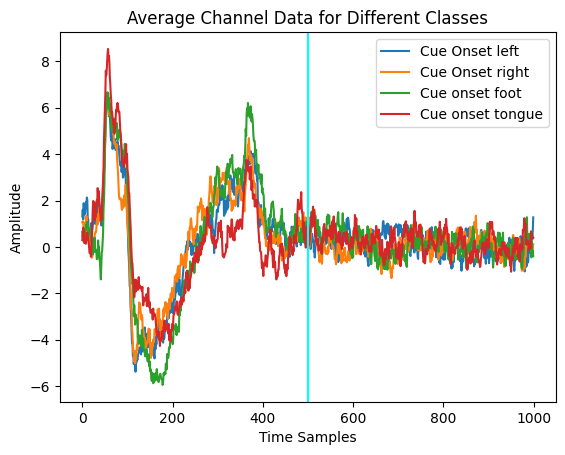

In [7]:

# Cue onset left - 0
# Cue onset right - 1
# Cue onset foot - 2
# Cue onset tongue - 3

y_train_valid -= 769
y_test -= 769

# ----------------------------
# Visualizing the Data
# ----------------------------

ch_data = X_train_valid[:,8,:] # extracts the 9th channel from the data


class_0_ind = np.where(y_train_valid == 0) # finds the indices where the label is 0
ch_data_class_0 = ch_data[class_0_ind] # finds the data where label is 0
avg_ch_data_class_0 = np.mean(ch_data_class_0,axis=0) # finds the average representation of the 9th channel when label is 0


class_1_ind = np.where(y_train_valid == 1)
ch_data_class_1 = ch_data[class_1_ind]
avg_ch_data_class_1 = np.mean(ch_data_class_1,axis=0)

class_2_ind = np.where(y_train_valid == 2)
ch_data_class_2 = ch_data[class_2_ind]
avg_ch_data_class_2 = np.mean(ch_data_class_2,axis=0)

class_3_ind = np.where(y_train_valid == 3)
ch_data_class_3 = ch_data[class_3_ind]
avg_ch_data_class_3 = np.mean(ch_data_class_3,axis=0)


plt.plot(np.arange(1000),avg_ch_data_class_0)
plt.plot(np.arange(1000),avg_ch_data_class_1)
plt.plot(np.arange(1000),avg_ch_data_class_2)
plt.plot(np.arange(1000),avg_ch_data_class_3)
plt.axvline(x=500, label='line at t=500',c='cyan')

plt.legend(["Cue Onset left", "Cue Onset right", "Cue onset foot", "Cue onset tongue"])
plt.title("Average Channel Data for Different Classes")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")

import os
plots_dir = "/content/drive/MyDrive/Colab Notebooks/new project/plots/"
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'avg_channel_data.png'))
plt.show()
plt.close()

In [ ]:
# ----------------------------
#  For reloading
# ----------------------------
# import importlib
# import src.preprocessing.data_prep as dp
# from src.models import cvae
# importlib.reload(dp)
# importlib.reload(cvae)

<module 'src.models.cvae' from '/content/drive/MyDrive/Colab Notebooks/cvae_project/src/models/cvae.py'>

In [8]:
# ----------------------------
#  Data Pre-Processing
# ----------------------------
x_train, x_valid, x_test, y_train, y_valid, y_test = dp.prepare_dataset(
    X_train_valid, y_train_valid, X_test, y_test, mode='cvae'
)

RUNNING NEW VERSION OF prepare_dataset
Shape of X after trimming: (1740, 22, 500)
Shape of X after maxpooling: (1740, 22, 250)
Shape of X after averaging+noise and concatenating: (3480, 22, 250)
Shape of X after subsampling and concatenating: (6960, 22, 250)
Shape of X after trimming: (375, 22, 500)
Shape of X after maxpooling: (375, 22, 250)
Shape of X after averaging+noise and concatenating: (750, 22, 250)
Shape of X after subsampling and concatenating: (1500, 22, 250)
Shape of X after trimming: (443, 22, 500)
Shape of X after maxpooling: (443, 22, 250)
Shape of X after averaging+noise and concatenating: (886, 22, 250)
Shape of X after subsampling and concatenating: (1772, 22, 250)
Shape of testing set: (1772, 22, 250)
Shape of testing labels: (1772,)
Shape of training set: (6960, 22, 250)
Shape of validation set: (1500, 22, 250)
Shape of training labels: (6960,)
Shape of validation labels: (1500,)
Shape of training labels after categorical conversion: (6960, 4)
Shape of validation l

# Convolutional Variational Auto-Encoder
We aim to extract meaningful features from the data while reducing noise and redundancy before classification. The EEG data (22×250×1) is compressed into a low-dimensional latent space (e.g., 16 dimensions) using a Convolutional VAE. The decoder reconstructs the original input shape, creating the mapping X → Z → Z(X), and only Z(X) [=] X is used during training.

By varying the latent dimension, we explore whether a smaller representation encourages the CVAE to focus on feature quality rather than reconstruction accuracy, improving generalization and reducing overfitting.

We also reduced the convolutional filter sizes from (64,32,16) to (32,16,8), decreasing model capacity to promote robust, generalizable feature representations while lowering memory and computational cost.

# Experiment 1: Latent Dimension Sweep for Classification Performance
Detemining the best latent dimension (6,8,12,16) to enhance classification accuracy using a Convolutional Variational Auto-Encoder + MLP.


In [9]:
input_shape = (22, 250, 1)
latent_dims = [6,8,12,16]
results = [] # for storing validation and test accuracies
best_latent_dim = None
all_histories = {}
best_val_acc = 0.2 #We start with a very low validation accuracy


for latent_dim in latent_dims:
    print(f"\n Training with latent_dim = {latent_dim}")

    # ----------------------------
    # Build model
    # ----------------------------
    encoder, shape_before_flatten = cvae.build_encoder(input_shape, latent_dim)
    decoder = cvae.build_decoder(latent_dim, shape_before_flatten)
    cvae_model = cvae.CVAE(encoder, decoder)
    cvae_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse')

    # Build model (important for saving later)
    cvae_model.build(input_shape=(None, *input_shape))

    # ----------------------------
    # Train VAE (fit() automatically uses custom training logic, train_step)
    # ----------------------------
    cvae_model.fit(
        x_train,
        epochs=10,
        batch_size=32,
        validation_data=(x_valid, x_valid),
        verbose=1
    )

    # ----------------------------
    # Extract latent space
    # ----------------------------
    z_mean_train, _, _ = encoder.predict(x_train)
    z_mean_valid, _, _ = encoder.predict(x_valid)
    z_mean_test,  _, _ = encoder.predict(x_test)

    # ----------------------------
    # Build classifier (MLP)
    # ----------------------------
    classifier = tf.keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(y_train.shape[1], activation='softmax')
    ])

    classifier.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # ----------------------------
    # Train classifier
    # ----------------------------
    history = classifier.fit(
        z_mean_train, y_train,
        validation_data=(z_mean_valid, y_valid),
        epochs=20,
        batch_size=64,
        verbose=1
    )
    all_histories[latent_dim] = history.history
    # ----------------------------
    # Evaluate
    # ----------------------------
    val_acc = max(history.history['val_accuracy'])
    test_loss, test_acc = classifier.evaluate(z_mean_test, y_test, verbose=0)
    print(f" Best val accuracy: {val_acc:.4f}")
    print(f" Test accuracy: {test_acc:.4f}")
    results.append((latent_dim, val_acc, test_acc))

    # ----------------------------
    # Save best model
    # ----------------------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_latent_dim = latent_dim

        encoder.save_weights(
            f"weights/best_encoder_ld{latent_dim}.weights.h5"
        )
        classifier.save_weights(
            f"weights/best_classifier_ld{latent_dim}.weights.h5"
        )
        print("Saved BEST model!")


 Training with latent_dim = 6
the output encoder shape of x is  (None, 3, 32, 32)
<class 'tuple'>
(3, 32, 32)
Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 68s 295ms/step - kl_loss: 1597.7592 - loss: 108.4069 - reconstruction_loss: 108.2472 - val_loss: 105.9197
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 61s 279ms/step - kl_loss: 4394.9023 - loss: 93.1462 - reconstruction_loss: 92.7067 - val_loss: 94.1283
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 62s 286ms/step - kl_loss: 2217.5273 - loss: 82.6466 - reconstruction_loss: 82.4248 - val_loss: 90.9940
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 62s 286ms/step - kl_loss: 1641.2076 - loss: 84.3054 - reconstruction_loss: 84.1413 - val_loss: 90.3783
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 61s 279ms/step - kl_loss: 1637.9750 - loss: 88.3794 - reconstruction_loss: 88.2156 - val_loss: 90.1321
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 88s 308ms/step - kl_loss: 1188.7899 - loss: 99.8579 - reconstruction_loss: 99.7390 - val_loss: 89.9933
Epoch 7/10
218/218 ━━━━━━━━━

In [10]:
print("\n Results:")
for ld, val_acc, test_acc in results:
    print(f"Latent Dim {ld}: Val Acc = {val_acc:.4f}")
    print(f"Latent Dim {ld}: Test Acc = {test_acc:.4f}")

print(f"\n Best latent_dim = {best_latent_dim}, Accuracy = {best_val_acc:.4f}")


 Results:
Latent Dim 6: Val Acc = 0.3227
Latent Dim 6: Test Acc = 0.3578
Latent Dim 8: Val Acc = 0.3700
Latent Dim 8: Test Acc = 0.3510
Latent Dim 12: Val Acc = 0.3247
Latent Dim 12: Test Acc = 0.3471
Latent Dim 16: Val Acc = 0.3420
Latent Dim 16: Test Acc = 0.3668

 Best latent_dim = 8, Accuracy = 0.3700


# Experiment 1 Results:
latent dim = 8: best on the validation accuracy

latent dim = 16: best on the test accuracy

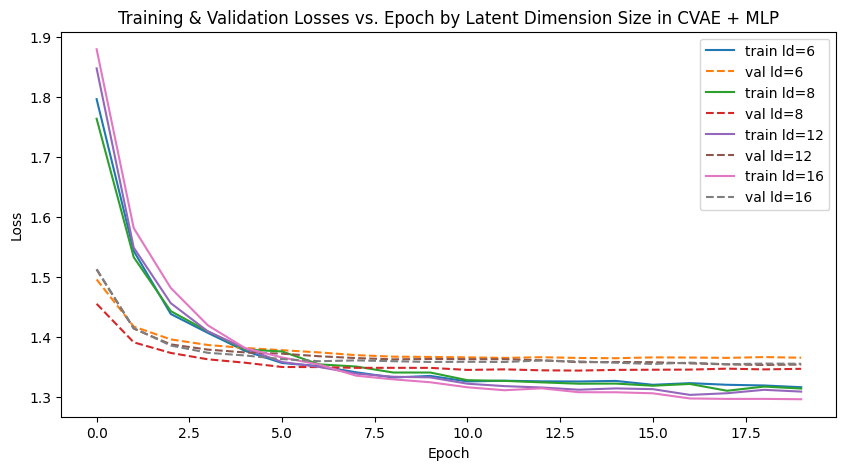

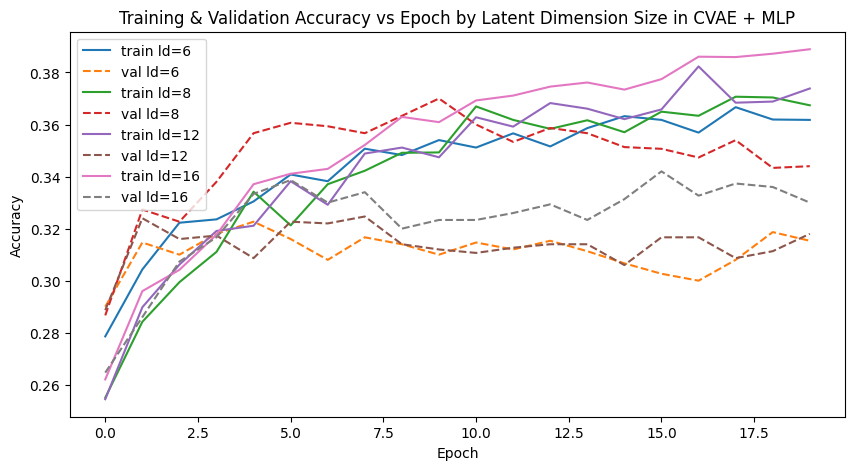

In [11]:
# Plotting Loss and Accuracy vs Epoch for each latent dimension

# Loss plot
plt.figure(figsize=(10, 5))
for ld, hist in all_histories.items():
    plt.plot(hist['loss'], label=f'train ld={ld}')
    plt.plot(hist['val_loss'], '--', label=f'val ld={ld}')
plt.title('Training & Validation Losses vs. Epoch by Latent Dimension Size in CVAE + MLP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plots_dir = "plots/"
plt.savefig(os.path.join(plots_dir, 'latent_space_loss.png'))
plt.show()

# Accuracy plot (for tracking accuracy in MLP classifier)
plt.figure(figsize=(10, 5))
for ld, hist in all_histories.items():
    if 'accuracy' in hist:
        plt.plot(hist['accuracy'], label=f'train ld={ld}')
        plt.plot(hist['val_accuracy'], '--', label=f'val ld={ld}')
plt.title('Training & Validation Accuracy vs Epoch by Latent Dimension Size in CVAE + MLP')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plots_dir = "plots/"
plt.savefig(os.path.join(plots_dir, 'latent_space_accuracy.png'))
plt.show()

# Experiment 2: Latent Space Visualization
Feature Visualization (t-SNE, PCA) using best encoder weights from Experiment 1 (LD=8).


In [12]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap


encoder, shape_before_flatten = cvae.build_encoder((22, 250, 1), 8)
encoder.load_weights(
    f"weights/best_encoder_ld{best_latent_dim}.weights.h5"
)
z_mean_train, _, _ = encoder.predict(x_train)
z_mean_test, _, _ = encoder.predict(x_test)

the output encoder shape of x is  (None, 3, 32, 32)
218/218 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step


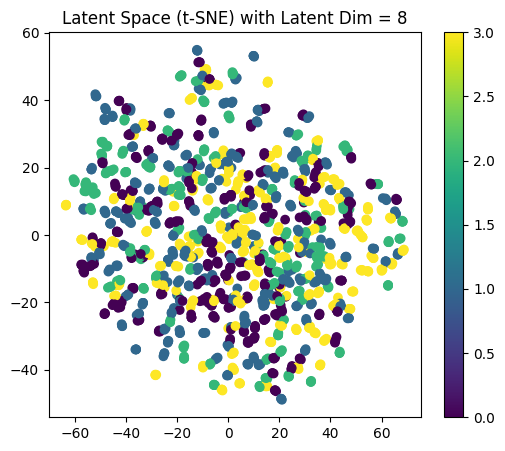

In [13]:

tsne = TSNE(n_components=2, perplexity=30)
z_2d = tsne.fit_transform(z_mean_test)

plt.figure(figsize=(6,5))
plt.scatter(z_2d[:,0], z_2d[:,1], c=y_test.argmax(axis=1), cmap='viridis')
plt.colorbar()
plt.title("Latent Space (t-SNE) with Latent Dim = 8")
import os
plots_dir = "plots/"
os.makedirs(plots_dir, exist_ok=True)
plt.savefig(os.path.join(plots_dir, 'latent_space_tsne.png'))
plt.show()
plt.close()

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step


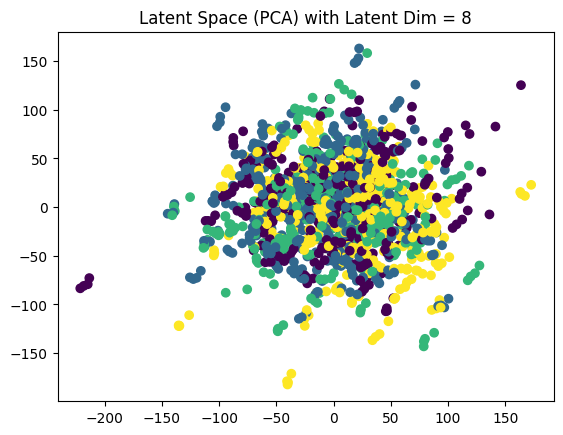

In [14]:

z_mean_test, _, _ = encoder.predict(x_test)
z_2d = PCA(n_components=2).fit_transform(z_mean_test)

plt.scatter(z_2d[:,0], z_2d[:,1], c=y_test.argmax(axis=1), cmap='viridis')
plt.title("Latent Space (PCA) with Latent Dim = 8")
plt.show()

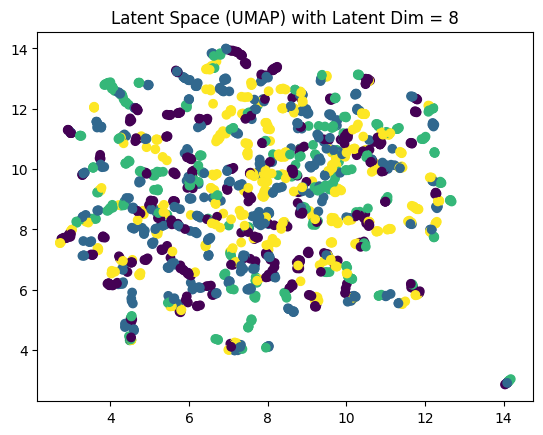

In [15]:

reducer = umap.UMAP()
z_2d = reducer.fit_transform(z_mean_test)

plt.scatter(z_2d[:,0], z_2d[:,1], c=y_test.argmax(axis=1), cmap='viridis')
plt.title("Latent Space (UMAP) with Latent Dim = 8")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
<class 'tuple'>
(3, 32, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


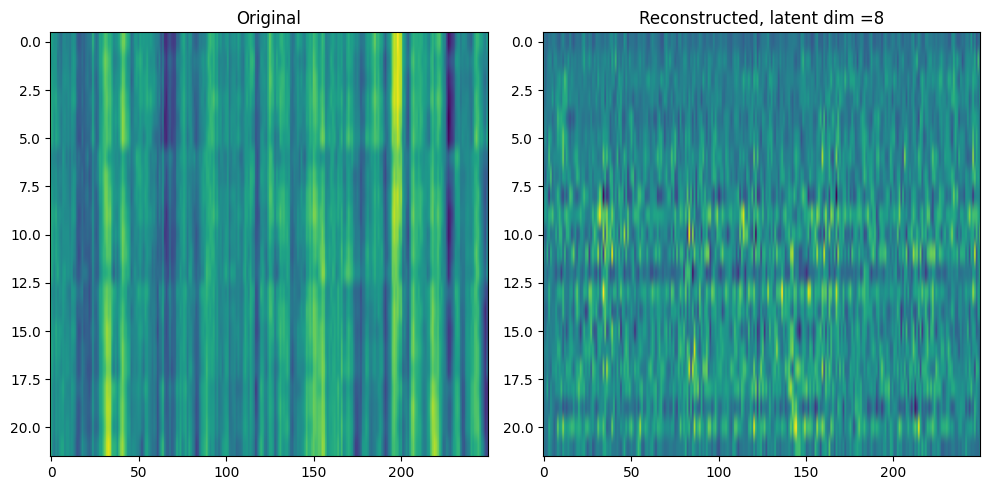

In [16]:
idx = 0

original = x_test[idx]
z_mean_test, _, z = encoder.predict(x_test[idx:idx+1])

# Re-instantiate the decoder with the best_latent_dim to match the encoder's output
decoder = cvae.build_decoder(8, shape_before_flatten)

# Reconstruct using decoder
reconstructed = decoder.predict(z_mean_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original.squeeze(), aspect='auto')
axes[0].set_title("Original")

axes[1].imshow(reconstructed.squeeze(), aspect='auto')
axes[1].set_title("Reconstructed, latent dim =8")

plt.tight_layout()
import os
plots_dir = "plots/"
plt.savefig(os.path.join(plots_dir, f'original_reconstructed_sample_{idx}.png'))
plt.show()
plt.close()

# Experiment 2 Results:
The latent space captures signal statistics but not class-discriminative structure. The reconstruction results show the model learns broad amplitude and spatial patterns while losing precise temporal features, which are likely where the motor imagery signal lives. The absence of class separation in PCA, UMAP and t-SNE suggests that the CVAE's reconstruction objective is not aligning the latent space with class boundaries. Intra-class variance dominates inter-class variance. The discriminative information encoded in the latent space, which yielded 0.380 accuracy on the validation data, is distributed across all 8 dimensions in a way that is not visible in a 2D projection.

# Experiment 3: Latent Dimension and KL Weight Sweep for Reconstruction Quality
CVAEs were trained with all combination of the following latent dimensions and KL divergence weights:
`latent_dims = [2, 4, 8, 12, 16, 24]`
`kl_weights = [1e-4, 1e-3, 1e-2, 1e-1]` . The purpose of this experiment is to observe the effect of KL weight and latent dimension on the reconstruction.

In [ ]:
latent_dims = [2, 4, 8, 12, 16, 24]
kl_weights = [1e-4, 1e-3, 1e-2, 1e-1]


idx = 0  # sample to visualize

for latent_dim in latent_dims:
    for kl_weight in kl_weights:

        print(f"Running latent_dim={latent_dim}, kl={kl_weight}")

        # -----------------
        # Build + train
        # -----------------
        encoder, shape_before_flatten = cvae.build_encoder(input_shape, latent_dim)
        decoder = cvae.build_decoder(latent_dim, shape_before_flatten)

        model = cvae.CVAE(encoder, decoder, kl_weight=kl_weight)
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-4))

        model.fit(x_train, epochs=10, batch_size=32, verbose=0)

        # -----------------
        # Reconstruction (single example)
        # -----------------
        original = x_test[idx]

        z_mean_test, _, _ = encoder.predict(x_test)
        z_sample = z_mean_test[idx:idx+1]

        reconstructed = decoder.predict(z_sample)

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(original.squeeze(), aspect='auto')
        axes[0].set_title("Original")

        axes[1].imshow(reconstructed.squeeze(), aspect='auto')
        axes[1].set_title(f"Recon (ld={latent_dim}, kl={kl_weight})")

        plt.tight_layout()
        plt.savefig(f"plots/recon_ld{latent_dim}_kl{kl_weight}.png")
        plt.close()

        # -----------------
        # t-SNE
        # -----------------
        tsne = TSNE(n_components=2, perplexity=30)
        z_2d = tsne.fit_transform(z_mean_test)

        plt.figure(figsize=(6,5))
        plt.scatter(z_2d[:,0], z_2d[:,1],
                    c=y_test.argmax(axis=1), cmap='viridis')
        plt.title(f"t-SNE (ld={latent_dim}, kl={kl_weight})")

        plt.savefig(f"plots/tsne_ld{latent_dim}_kl{kl_weight}.png")
        plt.close()

        # -----------------
        # UMAP
        # -----------------
        reducer = umap.UMAP()
        z_2d = reducer.fit_transform(z_mean_test)

        plt.figure(figsize=(6,5))
        plt.scatter(z_2d[:,0], z_2d[:,1],
                    c=y_test.argmax(axis=1), cmap='viridis')
        plt.title(f"UMAP (ld={latent_dim}, kl={kl_weight})")

        plt.savefig(f"plots/umap_ld{latent_dim}_kl{kl_weight}.png")
        plt.close()

Running latent_dim=2, kl=0.0001
the output encoder shape of x is  (None, 3, 32, 32)
<class 'tuple'>
(3, 32, 32)
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Running latent_dim=2, kl=0.001
the output encoder shape of x is  (None, 3, 32, 32)
<class 'tuple'>
(3, 32, 32)
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Running latent_dim=2, kl=0.01
the output encoder shape of x is  (None, 3, 32, 32)
<class 'tuple'>
(3, 32, 32)
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Running latent_dim=2, kl=0.1
the output encoder shape of x is  (None, 3, 32, 32)
<class 'tuple'>
(3, 32, 32)
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Running latent_dim=4, kl=0.0001
the output encoder shape of x is  (None, 3, 32, 32)
<class 'tuple'>
(3, 32, 32)
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Running latent_dim=4, kl=0.001
the output encoder s

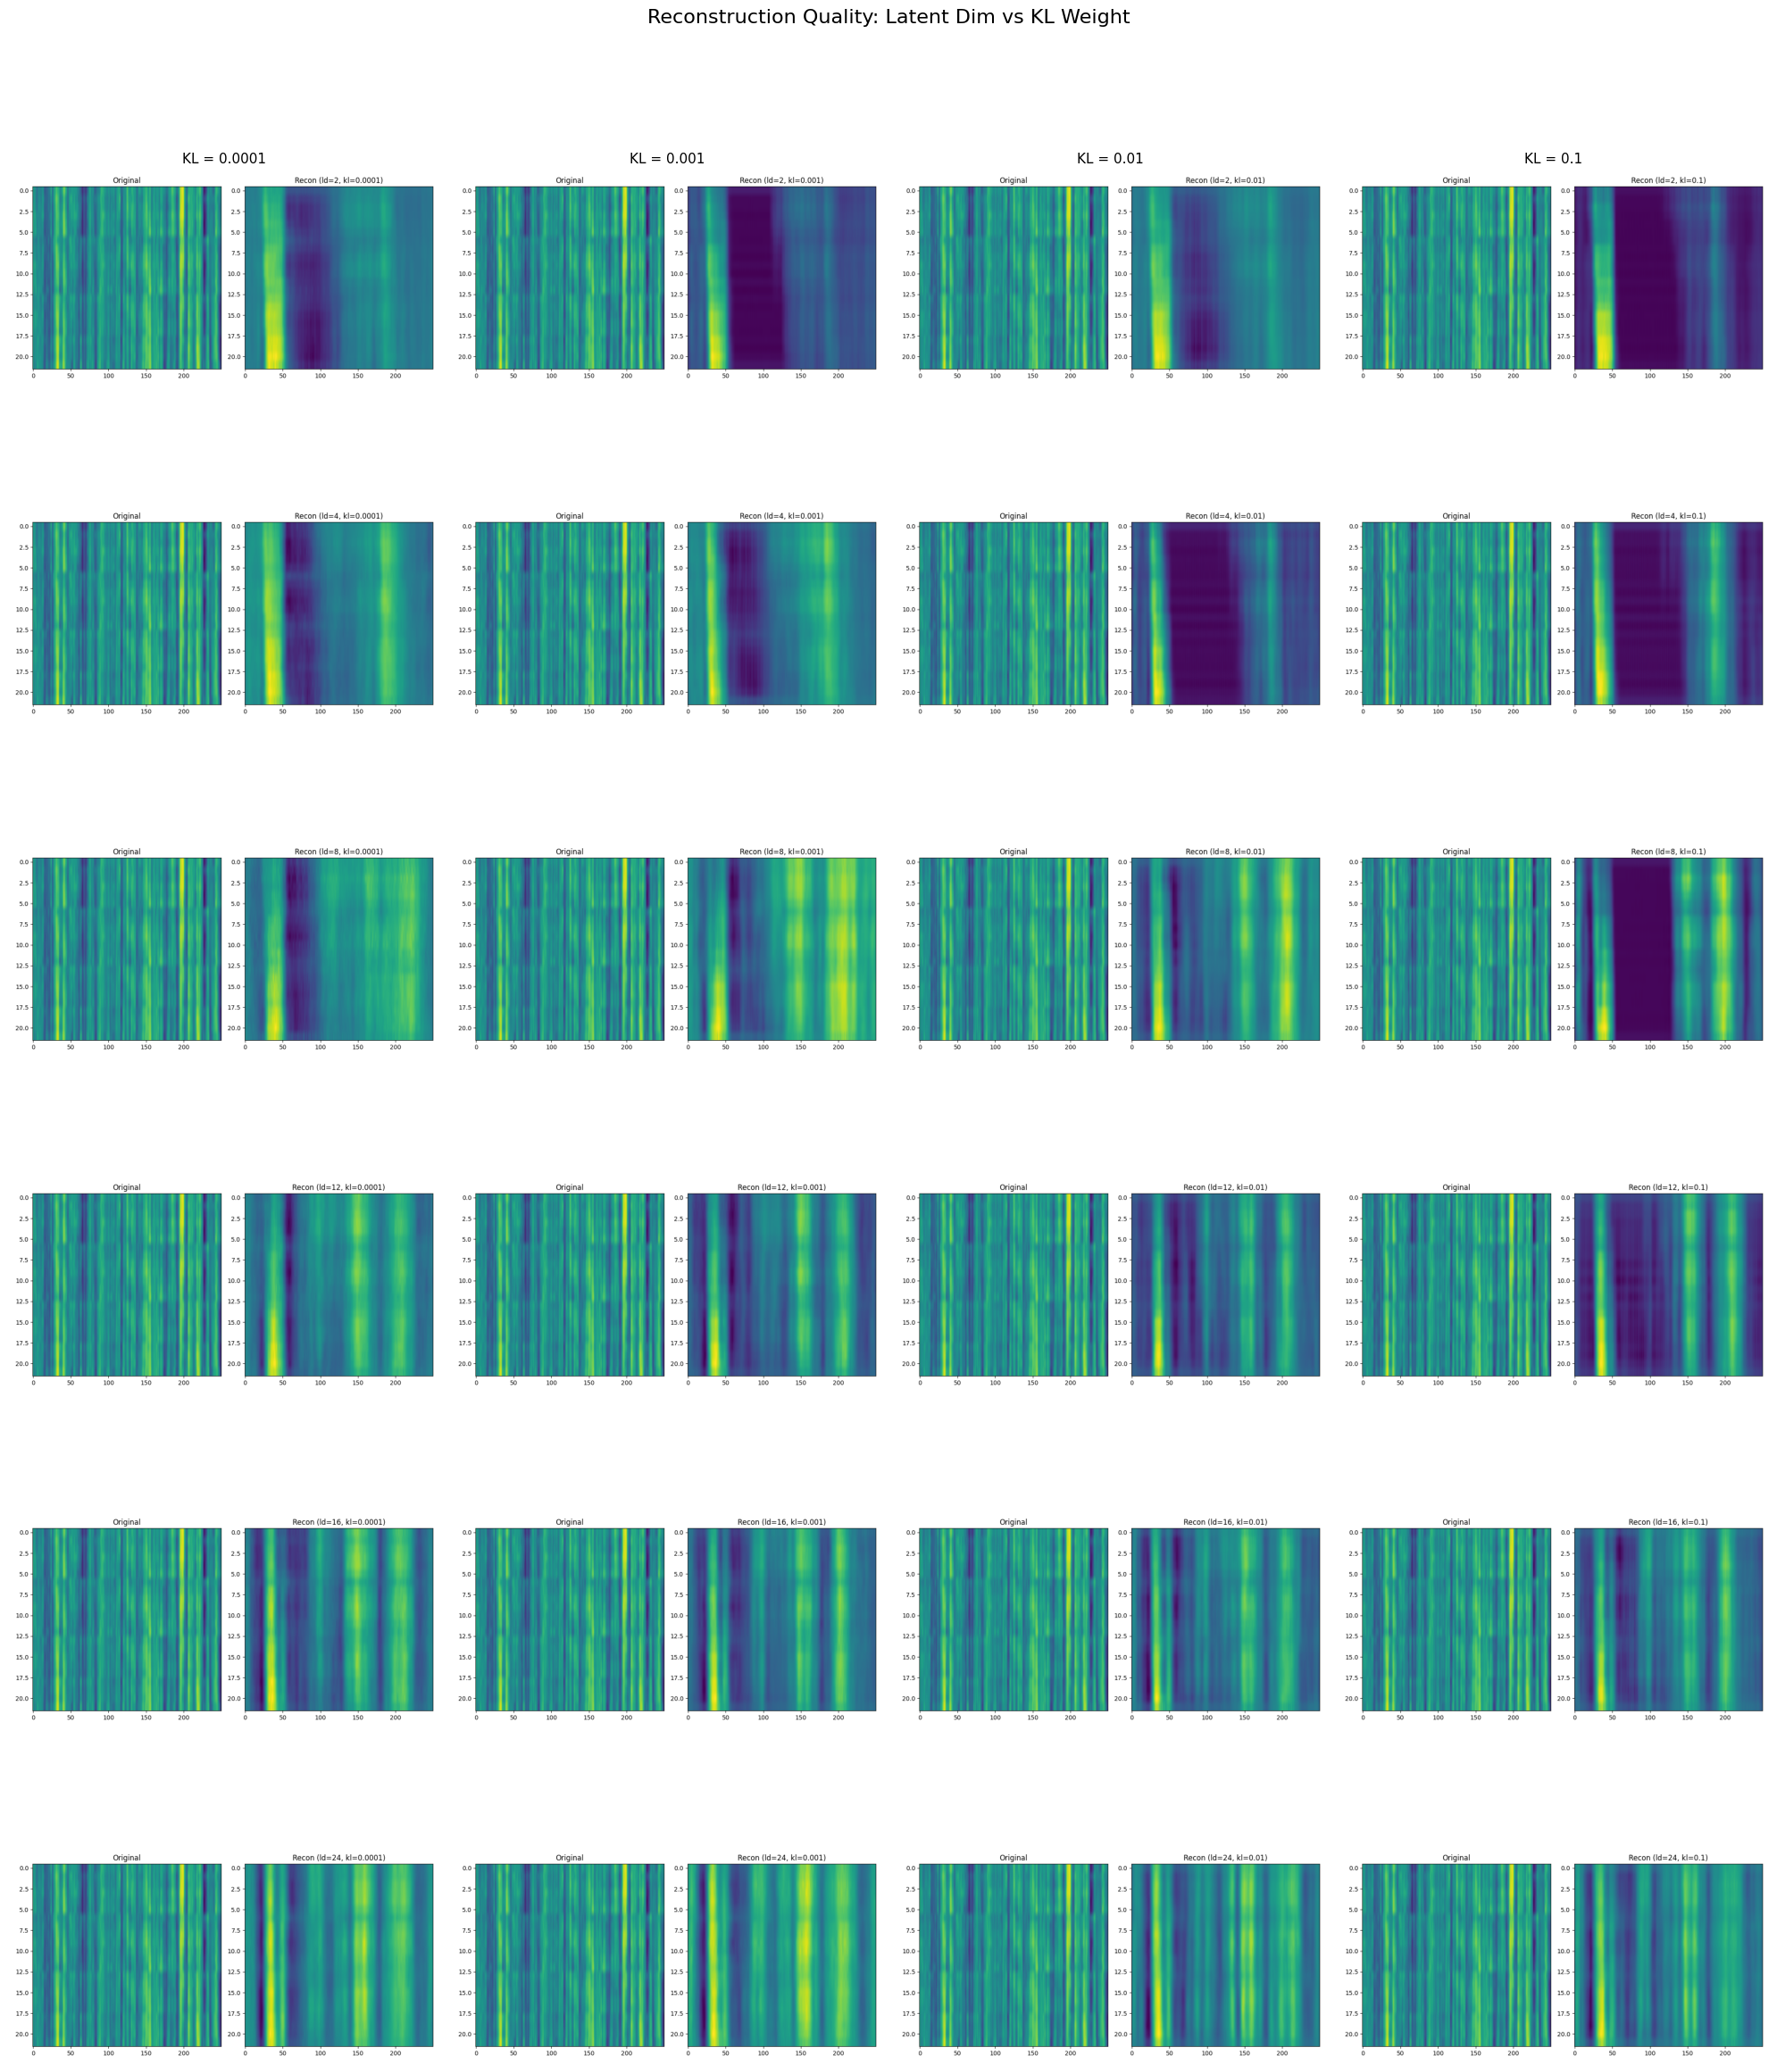

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

latent_dims = [2, 4, 8, 12, 16, 24]
kl_weights = [1e-4, 1e-3, 1e-2, 1e-1]

fig, axes = plt.subplots(6, 4, figsize=(20, 24))
fig.suptitle("Reconstruction Quality: Latent Dim vs KL Weight", fontsize=16, y=1.01)

for row, ld in enumerate(latent_dims):
    for col, kl in enumerate(kl_weights):
        ax = axes[row, col]

        # Format kl weight to match filename
        kl_str = f"{kl:.4g}"
        fname = f"recon_ld{ld}_kl{kl_str}.png"
        fpath = os.path.join("plots/", fname)

        if os.path.exists(fpath):
            img = mpimg.imread(fpath)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, f"Missing:\n{fname}", ha="center", va="center",
                    fontsize=8, color="red", transform=ax.transAxes)
            ax.set_facecolor("#f0f0f0")

        ax.axis("off")

        # Column headers on first row
        if row == 0:
            ax.set_title(f"KL = {kl:.4g}", fontsize=11, pad=6)

        # Row labels on first column
        if col == 0:
            ax.set_ylabel(f"LD = {ld}", fontsize=11, labelpad=6, rotation=0, ha="right", va="center")

plt.tight_layout()
plt.savefig("plots/reconstruction_grid.png", dpi=150, bbox_inches="tight")
plt.show()